# 의사결정나무 (Decision Tree)

## 학습 목표


**의사결정나무의 원리 이해** 지니 불순도(Gini Impurity)와 정보 이득(Information Gain) 개념을 수학적으로 이해함

**분류 모델 학습** `DecisionTreeClassifier`를 사용하여 제조 공정 상태 분류 모델을 학습함

**트리 해석 능력** 트리 구조를 시각화하고 해석하여 특성 중요도를 분석함

**과대적합 진단** 과대적합(Overfitting) 현상을 이해하고 적절한 하이퍼파라미터를 선택함

**전처리 중요성 인식** 결측치 처리 전후 모델 성능 차이를 통해 데이터 전처리의 중요성을 체험함

---

## 실습 데이터셋 소개

### UCI Condition Monitoring of Hydraulic Systems Dataset

본 실습에서는 **유압 시스템 상태 모니터링 데이터셋**을 활용한다. 이 데이터셋은 실제 산업 현장의 유압 테스트 리그에서 수집된 센서 데이터로, 제조업의 설비 상태 진단(Predictive Maintenance) 문제를 대표하는 실제 데이터이다.

| 항목 | 내용 |
|------|------|
| **출처** | UCI Machine Learning Repository |
| **데이터 유형** | 다변량 시계열 (Multivariate Time-Series) |
| **샘플 수** | 2,205 사이클 |
| **센서 수** | 17개 센서 (압력, 온도, 유량, 진동 등) |
| **타겟 변수** | 밸브 상태, 펌프 누출, 축압기 상태, 냉각 효율 등 |
| **활용 분야** | 설비 예지 보전, 결함 진단, 품질 관리 |

### 왜 이 데이터셋인가?

1. **실제 제조 현장 데이터**: 합성 데이터가 아닌 실제 산업용 유압 시스템에서 수집
2. **다양한 센서 데이터**: 압력, 온도, 유량, 진동 등 제조업에서 흔히 사용되는 센서 포함
3. **결측치 및 노이즈 존재**: 실제 데이터의 특성을 반영하여 전처리의 중요성 학습 가능
4. **다중 클래스 분류**: 단순 이진 분류가 아닌 실용적인 다중 클래스 문제

---

# 1: 의사결정나무의 원리

## 1.1 의사결정나무(Decision Tree)란?

의사결정나무는 **질문을 통해 데이터를 분류하는 알고리즘**이다. 흔히 "스무고개" 게임에 비유할 수 있으며, 각 질문(분기점)에서 "예/아니오"로 답할 수 있는 조건을 기준으로 데이터를 분할하여 최종적으로 클래스(범주)를 결정한다.

### 핵심 아이디어

1. **질문 기반 분류**: 예/아니오로 답할 수 있는 질문을 던짐
2. **재귀적 분할**: 질문에 따라 데이터를 반복적으로 나눔
3. **리프 노드에서 결정**: 최종적으로 클래스(범주)를 할당

### 제조업 현장에서의 의사결정나무 예시

```
                    "온도 > 85도 인가?"
                           |
              +------------+------------+
             예                        아니오
              |                          |
    "진동 > 2.5mm/s 인가?"        "압력 < 10bar 인가?"
             |                          |
        +----+----+                +----+----+
       예        아니오           예        아니오
        |          |              |          |
    [고장 위험]  [주의]       [누출 의심]   [정상]
```

이처럼 의사결정나무는 **명확한 규칙(Rule)** 을 제공하기 때문에 현장 작업자도 쉽게 이해하고 적용할 수 있다는 장점이 있다.

## 1.2 트리 구조 용어 정의

의사결정나무의 구조를 이해하기 위한 핵심 용어를 정리한다.

```
            [루트 노드]           <-- 첫 번째 질문 (가장 중요한 특성으로 분할)
                 |
          +------+------+
          |             |
    [내부 노드]    [내부 노드]   <-- 추가 질문 (조건에 따라 분기)
          |             |
      +---+---+    +----+----+
      |       |    |         |
   [리프]  [리프] [리프]   [리프]   <-- 최종 결정 (클래스 할당)
```

| 용어 | 영문 | 설명 |
|------|------|------|
| **루트 노드** | Root Node | 첫 번째 분기점으로, 가장 중요한 특성으로 분할 수행 |
| **내부 노드** | Internal Node | 중간 분기점으로, 추가적인 질문(조건)을 수행 |
| **리프 노드** | Leaf Node | 최종 결정 노드로, 클래스가 할당됨 |
| **깊이** | Depth | 루트에서 리프까지의 최대 경로 길이 |
| **가지** | Branch | 노드 간 연결로, 분할 조건을 나타냄 |

## 1.3 의사결정나무 학습 프로세스

의사결정나무가 학습되는 과정은 다음과 같은 흐름으로 진행된다.

```mermaid
flowchart TD
    A[전체 데이터] --> B{최적 분할점 탐색}
    B --> C[모든 특성의 모든 분할점 검토]
    C --> D[불순도 감소량 계산]
    D --> E{정보 이득이 가장 큰 분할 선택}
    E --> F[데이터 분할]
    F --> G{종료 조건 확인}
    G -->|깊이 도달| H[리프 노드 생성]
    G -->|샘플 부족| H
    G -->|순수 노드| H
    G -->|계속| B
    H --> I[다수 클래스 할당]
```

### 핵심 원리: 불순도(Impurity) 최소화

의사결정나무의 학습 목표는 각 분할에서 **불순도를 최대한 감소**시키는 것이다.

- **불순도**: 데이터가 얼마나 "섞여있는지" 측정하는 지표
- **좋은 분할**: 분할 후 각 그룹이 한 클래스로 통일되어 불순도가 낮아짐
- **나쁜 분할**: 분할 후에도 클래스가 섞여 있어 불순도가 여전히 높음

```
[분할 전]
정상 정상 정상 정상 | 불량 불량 불량 불량    (50% 정상, 50% 불량)

[분할 A - 좋은 분할]
왼쪽: 정상 정상 정상 정상    오른쪽: 불량 불량 불량 불량
      (100% 정상)                  (100% 불량)  --> 불순도 0

[분할 B - 나쁜 분할]
왼쪽: 정상 정상 불량 불량    오른쪽: 정상 정상 불량 불량
      (50% 정상)                   (50% 정상)  --> 불순도 여전히 높음
```

## 2.1 지니 불순도 (Gini Impurity)

**지니 불순도**는 가장 널리 사용되는 불순도 측정 방식으로, scikit-learn의 기본값이다.

### 수식 정의

$$\text{Gini}(D) = 1 - \sum_{i=1}^{c} p_i^2$$

여기서:
- $D$: 현재 노드의 데이터셋
- $c$: 클래스의 개수
- $p_i$: 클래스 $i$에 속하는 샘플의 비율 ($p_i = \frac{n_i}{N}$, $n_i$는 클래스 $i$의 샘플 수, $N$은 전체 샘플 수)

### 수식의 직관적 이해

지니 불순도는 **무작위로 선택한 샘플이 잘못 분류될 확률**을 의미한다.

- 각 클래스 $i$가 선택될 확률: $p_i$
- 선택된 샘플이 해당 클래스가 아닌 다른 클래스로 잘못 분류될 확률: $1 - p_i$
- 따라서 전체 오분류 확률: $\sum_{i=1}^{c} p_i (1-p_i) = 1 - \sum_{i=1}^{c} p_i^2$

### 지니 불순도의 특성

| 상황 | Gini 값 | 해석 |
|------|---------|------|
| 한 클래스만 존재 | 0 | 완전히 순수 (Pure) |
| 이진 분류에서 50:50 | 0.5 | 가장 불순 (Maximum Impurity) |
| 3클래스 균등 분포 (33:33:33) | 0.667 | 다중 클래스 최대 불순도 |

### 지니 불순도 계산 예시

제조 공정에서 제품 상태를 분류하는 상황을 가정하자.

**Case A: 정상 10개, 불량 0개 (완전 순수)**

$$\text{Gini} = 1 - \left(\frac{10}{10}\right)^2 - \left(\frac{0}{10}\right)^2 = 1 - 1 - 0 = 0$$

**Case B: 정상 5개, 불량 5개 (가장 불순)**

$$\text{Gini} = 1 - \left(\frac{5}{10}\right)^2 - \left(\frac{5}{10}\right)^2 = 1 - 0.25 - 0.25 = 0.5$$

**Case C: 정상 80개, 불량 20개 (다소 순수)**

$$\text{Gini} = 1 - \left(\frac{80}{100}\right)^2 - \left(\frac{20}{100}\right)^2 = 1 - 0.64 - 0.04 = 0.32$$

In [1]:
# 지니 불순도 직접 계산 및 이해
import numpy as np

def gini_impurity(class_counts):
    """
    지니 불순도를 계산하는 함수
    
    Parameters:
    -----------
    class_counts : list or array
        각 클래스별 샘플 수 (예: [80, 20]은 정상 80개, 불량 20개)
    
    Returns:
    --------
    float : 지니 불순도 값 (0 ~ 0.5 범위, 이진 분류 기준)
    
    Mathematical Background:
    ------------------------
    Gini(D) = 1 - sum(p_i^2) for i in classes
    
    - p_i = n_i / N (클래스 i의 비율)
    - 완전 순수: Gini = 0
    - 완전 불순 (50:50): Gini = 0.5
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    
    # 각 클래스 비율의 제곱 합
    proportions_squared = [(count / total) ** 2 for count in class_counts]
    
    return 1 - sum(proportions_squared)

# 예시 계산
print("=" * 60)
print("지니 불순도 계산 예시")
print("=" * 60)

cases = [
    ("Case A: 정상 10개, 불량 0개 (완전 순수)", [10, 0]),
    ("Case B: 정상 5개, 불량 5개 (가장 불순)", [5, 5]),
    ("Case C: 정상 80개, 불량 20개 (다소 순수)", [80, 20]),
    ("Case D: 정상 90개, 불량 10개 (대부분 정상)", [90, 10]),
]

for name, counts in cases:
    gini = gini_impurity(counts)
    total = sum(counts)
    print(f"\n{name}")
    print(f"  정상 비율: {counts[0]/total:.1%}, 불량 비율: {counts[1]/total:.1%}")
    print(f"  Gini 불순도: {gini:.4f}")
    
    # 수식 전개 표시
    p1, p2 = counts[0]/total, counts[1]/total
    print(f"  수식: 1 - ({p1:.2f})^2 - ({p2:.2f})^2 = 1 - {p1**2:.4f} - {p2**2:.4f} = {gini:.4f}")

지니 불순도 계산 예시

Case A: 정상 10개, 불량 0개 (완전 순수)
  정상 비율: 100.0%, 불량 비율: 0.0%
  Gini 불순도: 0.0000
  수식: 1 - (1.00)^2 - (0.00)^2 = 1 - 1.0000 - 0.0000 = 0.0000

Case B: 정상 5개, 불량 5개 (가장 불순)
  정상 비율: 50.0%, 불량 비율: 50.0%
  Gini 불순도: 0.5000
  수식: 1 - (0.50)^2 - (0.50)^2 = 1 - 0.2500 - 0.2500 = 0.5000

Case C: 정상 80개, 불량 20개 (다소 순수)
  정상 비율: 80.0%, 불량 비율: 20.0%
  Gini 불순도: 0.3200
  수식: 1 - (0.80)^2 - (0.20)^2 = 1 - 0.6400 - 0.0400 = 0.3200

Case D: 정상 90개, 불량 10개 (대부분 정상)
  정상 비율: 90.0%, 불량 비율: 10.0%
  Gini 불순도: 0.1800
  수식: 1 - (0.90)^2 - (0.10)^2 = 1 - 0.8100 - 0.0100 = 0.1800


## 2.2 엔트로피 (Entropy)

**엔트로피**는 정보이론(Information Theory)에 기반한 불순도 측정 방식이다.

### 수식 정의

$$H(D) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

여기서:
- $H(D)$: 데이터셋 $D$의 엔트로피
- $p_i$: 클래스 $i$에 속하는 샘플의 비율
- $\log_2$: 밑이 2인 로그 (비트 단위 정보량)

**참고**: $p_i = 0$일 경우, $0 \cdot \log_2(0)$는 극한값으로 0으로 정의한다.

$$\lim_{p \to 0^+} p \log_2(p) = 0$$

### 정보이론적 해석

엔트로피는 **데이터의 불확실성(Uncertainty)** 또는 **평균 정보량**을 측정한다.

- 클래스가 하나만 존재하면 불확실성이 없으므로 엔트로피 = 0
- 클래스가 균등하게 분포하면 불확실성이 최대이므로 엔트로피 = 최대값

### 엔트로피의 특성

| 상황 | 엔트로피 값 | 해석 |
|------|------------|------|
| 한 클래스만 존재 | 0 | 완전히 순수 (불확실성 없음) |
| 이진 분류에서 50:50 | 1 | 가장 불순 (최대 불확실성) |
| 3클래스 균등 분포 | 1.585 | 다중 클래스 최대 엔트로피 |

### 엔트로피 계산 예시

**Case A: 정상 10개, 불량 0개 (완전 순수)**

$$H = -\left(\frac{10}{10} \log_2 \frac{10}{10}\right) - \left(\frac{0}{10} \log_2 \frac{0}{10}\right) = -1 \cdot 0 - 0 = 0$$

**Case B: 정상 5개, 불량 5개 (가장 불순)**

$$H = -\left(\frac{5}{10} \log_2 \frac{5}{10}\right) - \left(\frac{5}{10} \log_2 \frac{5}{10}\right)$$

$$H = -0.5 \cdot (-1) - 0.5 \cdot (-1) = 0.5 + 0.5 = 1$$

**Case C: 정상 80개, 불량 20개**

$$H = -\left(0.8 \cdot \log_2 0.8\right) - \left(0.2 \cdot \log_2 0.2\right)$$

$$H = -0.8 \cdot (-0.322) - 0.2 \cdot (-2.322) = 0.258 + 0.464 = 0.722$$

In [2]:
# 엔트로피 계산 및 지니 불순도와 비교
import numpy as np

def entropy(class_counts):
    """
    엔트로피를 계산하는 함수
    
    Parameters:
    -----------
    class_counts : list or array
        각 클래스별 샘플 수
    
    Returns:
    --------
    float : 엔트로피 값 (0 ~ 1 범위, 이진 분류 기준)
    
    Mathematical Background:
    ------------------------
    H(D) = -sum(p_i * log2(p_i)) for i in classes
    
    정보이론에서 엔트로피는 '평균 정보량' 또는 '불확실성'을 의미한다.
    - p_i가 0이면 해당 항은 0으로 처리 (0 * log(0) = 0)
    """
    total = sum(class_counts)
    if total == 0:
        return 0
    
    entropy_value = 0
    for count in class_counts:
        if count > 0:
            p = count / total
            entropy_value -= p * np.log2(p)
    
    return entropy_value

# 지니 불순도와 엔트로피 비교
print("=" * 70)
print("지니 불순도 vs 엔트로피 비교")
print("=" * 70)
print(f"{'상황':<35} {'Gini':>10} {'Entropy':>10}")
print("-" * 70)

comparison_cases = [
    ("정상 10개, 불량 0개 (완전 순수)", [10, 0]),
    ("정상 5개, 불량 5개 (50:50)", [5, 5]),
    ("정상 8개, 불량 2개 (80:20)", [8, 2]),
    ("정상 9개, 불량 1개 (90:10)", [9, 1]),
    ("정상 7개, 불량 3개 (70:30)", [7, 3]),
]

for name, counts in comparison_cases:
    gini = gini_impurity(counts)
    ent = entropy(counts)
    print(f"{name:<35} {gini:>10.4f} {ent:>10.4f}")

지니 불순도 vs 엔트로피 비교
상황                                        Gini    Entropy
----------------------------------------------------------------------
정상 10개, 불량 0개 (완전 순수)                   0.0000     0.0000
정상 5개, 불량 5개 (50:50)                    0.5000     1.0000
정상 8개, 불량 2개 (80:20)                    0.3200     0.7219
정상 9개, 불량 1개 (90:10)                    0.1800     0.4690
정상 7개, 불량 3개 (70:30)                    0.4200     0.8813


## 2.3 정보 이득 (Information Gain)

**정보 이득**은 특정 특성으로 분할했을 때 **불순도가 얼마나 감소했는지**를 측정한다.

### 수식 정의

$$IG(D, A) = I(D) - \sum_{v \in \text{Values}(A)} \frac{|D_v|}{|D|} I(D_v)$$

여기서:
- $IG(D, A)$: 특성 $A$로 분할했을 때의 정보 이득
- $I(D)$: 분할 전 불순도 (부모 노드의 지니 또는 엔트로피)
- $D_v$: 특성 $A$의 값이 $v$인 부분집합
- $\frac{|D_v|}{|D|}$: 가중치 (부분집합의 비율)
- $I(D_v)$: 부분집합 $D_v$의 불순도

### 직관적 해석

$$\text{정보 이득} = \text{(분할 전 불순도)} - \text{(분할 후 가중 평균 불순도)}$$

- 정보 이득이 **클수록** 해당 분할이 **효과적**임
- 의사결정나무는 **정보 이득을 최대화하는 분할**을 선택함

### 정보 이득 계산 예시: 제조 공정 시나리오

**상황**: 부모 노드에 정상 50개, 불량 50개가 존재 (총 100개)

**분할 전 지니 불순도**:

$$\text{Gini}_{parent} = 1 - \left(\frac{50}{100}\right)^2 - \left(\frac{50}{100}\right)^2 = 0.5$$

---

**분할 A (좋은 분할)**: 온도 > 85도 기준으로 분할

| 노드 | 정상 | 불량 | 샘플 수 | 지니 |
|------|------|------|---------|------|
| 왼쪽 (온도 <= 85) | 45 | 5 | 50 | 0.18 |
| 오른쪽 (온도 > 85) | 5 | 45 | 50 | 0.18 |

$$\text{Gini}_{왼쪽} = 1 - (0.9)^2 - (0.1)^2 = 1 - 0.81 - 0.01 = 0.18$$

$$\text{Gini}_{오른쪽} = 1 - (0.1)^2 - (0.9)^2 = 1 - 0.01 - 0.81 = 0.18$$

$$\text{Gini}_{children} = \frac{50}{100} \times 0.18 + \frac{50}{100} \times 0.18 = 0.18$$

$$IG_A = 0.5 - 0.18 = 0.32$$

---

**분할 B (나쁜 분할)**: 습도 > 60% 기준으로 분할

| 노드 | 정상 | 불량 | 샘플 수 | 지니 |
|------|------|------|---------|------|
| 왼쪽 (습도 <= 60) | 25 | 25 | 50 | 0.5 |
| 오른쪽 (습도 > 60) | 25 | 25 | 50 | 0.5 |

$$\text{Gini}_{children} = \frac{50}{100} \times 0.5 + \frac{50}{100} \times 0.5 = 0.5$$

$$IG_B = 0.5 - 0.5 = 0$$

---

**결론**: 정보 이득이 더 큰 **분할 A를 선택** ($IG_A = 0.32 > IG_B = 0$)

In [3]:
# 정보 이득 계산 함수 및 시각화
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def information_gain(parent_counts, left_counts, right_counts, criterion='gini'):
    """
    정보 이득을 계산하는 함수
    
    Parameters:
    -----------
    parent_counts : list
        부모 노드의 클래스별 샘플 수
    left_counts : list
        왼쪽 자식 노드의 클래스별 샘플 수
    right_counts : list
        오른쪽 자식 노드의 클래스별 샘플 수
    criterion : str
        'gini' 또는 'entropy'
    
    Returns:
    --------
    float : 정보 이득
    """
    impurity_func = gini_impurity if criterion == 'gini' else entropy
    
    n_parent = sum(parent_counts)
    n_left = sum(left_counts)
    n_right = sum(right_counts)
    
    # 부모 노드 불순도
    parent_impurity = impurity_func(parent_counts)
    
    # 자식 노드 가중 평균 불순도
    left_impurity = impurity_func(left_counts)
    right_impurity = impurity_func(right_counts)
    
    weighted_child_impurity = (n_left/n_parent) * left_impurity + (n_right/n_parent) * right_impurity
    
    return parent_impurity - weighted_child_impurity

# 예시: 분할 A vs 분할 B 비교
print("=" * 70)
print("정보 이득 계산 예시: 분할 비교")
print("=" * 70)

# 부모 노드: 정상 50, 불량 50
parent = [50, 50]

# 분할 A: 온도 > 85도 (좋은 분할)
left_A = [45, 5]   # 온도 <= 85: 정상 45, 불량 5
right_A = [5, 45]  # 온도 > 85: 정상 5, 불량 45

# 분할 B: 습도 > 60% (나쁜 분할)
left_B = [25, 25]  # 습도 <= 60: 정상 25, 불량 25
right_B = [25, 25] # 습도 > 60: 정상 25, 불량 25

print(f"\n부모 노드: 정상 {parent[0]}개, 불량 {parent[1]}개")
print(f"부모 Gini: {gini_impurity(parent):.4f}")

print("\n" + "-" * 70)
print("분할 A (온도 > 85도)")
print(f"  왼쪽: 정상 {left_A[0]}, 불량 {left_A[1]} -> Gini: {gini_impurity(left_A):.4f}")
print(f"  오른쪽: 정상 {right_A[0]}, 불량 {right_A[1]} -> Gini: {gini_impurity(right_A):.4f}")
ig_A = information_gain(parent, left_A, right_A)
print(f"  정보 이득: {ig_A:.4f}")

print("\n" + "-" * 70)
print("분할 B (습도 > 60%)")
print(f"  왼쪽: 정상 {left_B[0]}, 불량 {left_B[1]} -> Gini: {gini_impurity(left_B):.4f}")
print(f"  오른쪽: 정상 {right_B[0]}, 불량 {right_B[1]} -> Gini: {gini_impurity(right_B):.4f}")
ig_B = information_gain(parent, left_B, right_B)
print(f"  정보 이득: {ig_B:.4f}")

print("\n" + "=" * 70)
print(f"결론: 분할 A 선택 (IG_A = {ig_A:.4f} > IG_B = {ig_B:.4f})")
print("=" * 70)

정보 이득 계산 예시: 분할 비교

부모 노드: 정상 50개, 불량 50개
부모 Gini: 0.5000

----------------------------------------------------------------------
분할 A (온도 > 85도)
  왼쪽: 정상 45, 불량 5 -> Gini: 0.1800
  오른쪽: 정상 5, 불량 45 -> Gini: 0.1800
  정보 이득: 0.3200

----------------------------------------------------------------------
분할 B (습도 > 60%)
  왼쪽: 정상 25, 불량 25 -> Gini: 0.5000
  오른쪽: 정상 25, 불량 25 -> Gini: 0.5000
  정보 이득: 0.0000

결론: 분할 A 선택 (IG_A = 0.3200 > IG_B = 0.0000)


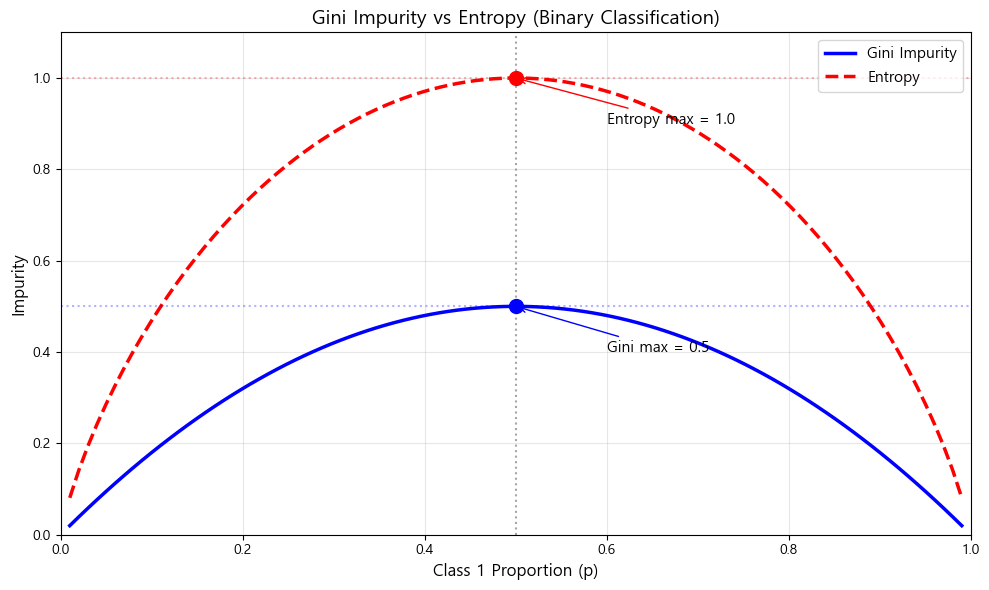


[해석]
1. 두 지표 모두 p=0.5 (50:50)일 때 최대값을 가짐
2. 지니 불순도의 최대값은 0.5, 엔트로피의 최대값은 1.0
3. 형태가 유사하여 실제로 비슷한 분할 결과를 생성함
4. scikit-learn 기본값은 지니 불순도 사용 (계산이 더 빠름)


In [4]:
# 지니 불순도 vs 엔트로피 시각화
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 시도 (없으면 영어로 대체)
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# p 값 범위 (0.01 ~ 0.99)
p = np.linspace(0.01, 0.99, 100)

# 지니 불순도: 1 - p^2 - (1-p)^2 = 2p(1-p)
gini = 1 - p**2 - (1-p)**2

# 엔트로피: -p*log2(p) - (1-p)*log2(1-p)
ent = -p * np.log2(p) - (1-p) * np.log2(1-p)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(p, gini, 'b-', linewidth=2.5, label='Gini Impurity')
ax.plot(p, ent, 'r--', linewidth=2.5, label='Entropy')

# 최대값 표시
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7)
ax.axhline(y=0.5, color='blue', linestyle=':', alpha=0.3)
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.3)

# 주요 포인트 표시
ax.scatter([0.5], [0.5], color='blue', s=100, zorder=5)
ax.scatter([0.5], [1.0], color='red', s=100, zorder=5)

ax.annotate('Gini max = 0.5', xy=(0.5, 0.5), xytext=(0.6, 0.4),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='blue'))
ax.annotate('Entropy max = 1.0', xy=(0.5, 1.0), xytext=(0.6, 0.9),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('Class 1 Proportion (p)', fontsize=12)
ax.set_ylabel('Impurity', fontsize=12)
ax.set_title('Gini Impurity vs Entropy (Binary Classification)', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('gini_vs_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print("1. 두 지표 모두 p=0.5 (50:50)일 때 최대값을 가짐")
print("2. 지니 불순도의 최대값은 0.5, 엔트로피의 최대값은 1.0")
print("3. 형태가 유사하여 실제로 비슷한 분할 결과를 생성함")
print("4. scikit-learn 기본값은 지니 불순도 사용 (계산이 더 빠름)")

---

# 3: 실습 - 유압 시스템 상태 분류

이제 실제 제조 데이터를 활용하여 의사결정나무 분류 모델을 학습한다.

## 3.1 데이터 로드 및 탐색

UCI Machine Learning Repository의 **Condition Monitoring of Hydraulic Systems** 데이터셋을 사용한다.

In [5]:
# 필요 라이브러리 설치 및 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# sklearn 관련 모듈
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

print("라이브러리 로드 완료")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

라이브러리 로드 완료
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


In [6]:
# UCI 유압 시스템 데이터셋 다운로드 및 로드
# 데이터셋 URL: https://archive.ics.uci.edu/ml/datasets/Condition+monitoring+of+hydraulic+systems

import urllib.request
import zipfile
import os

# 데이터 디렉토리 생성
data_dir = 'hydraulic_data'
os.makedirs(data_dir, exist_ok=True)

# UCI 데이터셋 URL (압축 파일)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00447/data.zip"
zip_path = os.path.join(data_dir, 'data.zip')

# 다운로드 (이미 있으면 스킵)
if not os.path.exists(zip_path):
    print("데이터셋 다운로드 중...")
    try:
        urllib.request.urlretrieve(url, zip_path)
        print("다운로드 완료!")
    except Exception as e:
        print(f"다운로드 실패: {e}")
        print("대체 데이터셋을 생성합니다...")
else:
    print("데이터셋이 이미 존재합니다.")

# 압축 해제
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("압축 해제 완료!")
        print(f"\n추출된 파일 목록:")
        for f in os.listdir(data_dir):
            print(f"  - {f}")
    except Exception as e:
        print(f"압축 해제 실패: {e}")

데이터셋 다운로드 중...
다운로드 완료!
압축 해제 완료!

추출된 파일 목록:
  - CE.txt
  - CP.txt
  - data.zip
  - description.txt
  - documentation.txt
  - EPS1.txt
  - FS1.txt
  - FS2.txt
  - profile.txt
  - PS1.txt
  - PS2.txt
  - PS3.txt
  - PS4.txt
  - PS5.txt
  - PS6.txt
  - SE.txt
  - TS1.txt
  - TS2.txt
  - TS3.txt
  - TS4.txt
  - VS1.txt


In [7]:
# 데이터 로드 및 전처리
# 실제 UCI 데이터가 없는 경우를 대비한 대체 로직 포함

def load_hydraulic_data(data_dir='hydraulic_data'):
    """
    유압 시스템 데이터셋 로드 함수
    
    UCI 데이터셋 구조:
    - PS1~PS6: 압력 센서 (6개)
    - EPS1: 모터 전력 센서
    - FS1, FS2: 유량 센서 (2개)
    - TS1~TS4: 온도 센서 (4개)
    - VS1: 진동 센서
    - CE: 냉각 효율
    - CP: 냉각 전력
    - SE: 효율 계수
    - profile: 타겟 변수들
    """
    
    try:
        # 센서 데이터 파일들 로드 시도
        # 각 센서 데이터는 별도 파일로 저장되어 있음
        
        # 압력 센서 데이터 (PS1 - 가장 중요한 센서)
        ps1 = pd.read_csv(os.path.join(data_dir, 'PS1.txt'), sep='\t', header=None)
        ps2 = pd.read_csv(os.path.join(data_dir, 'PS2.txt'), sep='\t', header=None)
        
        # 온도 센서 데이터
        ts1 = pd.read_csv(os.path.join(data_dir, 'TS1.txt'), sep='\t', header=None)
        ts2 = pd.read_csv(os.path.join(data_dir, 'TS2.txt'), sep='\t', header=None)
        
        # 유량 센서 데이터
        fs1 = pd.read_csv(os.path.join(data_dir, 'FS1.txt'), sep='\t', header=None)
        fs2 = pd.read_csv(os.path.join(data_dir, 'FS2.txt'), sep='\t', header=None)
        
        # 진동 센서
        vs1 = pd.read_csv(os.path.join(data_dir, 'VS1.txt'), sep='\t', header=None)
        
        # 냉각 효율
        ce = pd.read_csv(os.path.join(data_dir, 'CE.txt'), sep='\t', header=None)
        
        # 타겟 변수 (상태 프로파일)
        profile = pd.read_csv(os.path.join(data_dir, 'profile.txt'), sep='\t', header=None)
        
        # 각 센서의 평균값을 특성으로 사용 (시계열 -> 집계)
        df = pd.DataFrame({
            'PS1_mean': ps1.mean(axis=1),
            'PS1_std': ps1.std(axis=1),
            'PS2_mean': ps2.mean(axis=1),
            'PS2_std': ps2.std(axis=1),
            'TS1_mean': ts1.mean(axis=1),
            'TS1_std': ts1.std(axis=1),
            'TS2_mean': ts2.mean(axis=1),
            'TS2_std': ts2.std(axis=1),
            'FS1_mean': fs1.mean(axis=1),
            'FS1_std': fs1.std(axis=1),
            'FS2_mean': fs2.mean(axis=1),
            'FS2_std': fs2.std(axis=1),
            'VS1_mean': vs1.mean(axis=1),
            'VS1_std': vs1.std(axis=1),
            'CE_mean': ce.mean(axis=1),
        })
        
        # 타겟 변수: 밸브 상태 (profile의 첫 번째 열)
        # 100: 최적, 90: 약간 지연, 80: 심하게 지연, 73: 고장 근접
        df['valve_condition'] = profile.iloc[:, 0]
        
        print(f"UCI 데이터셋 로드 성공!")
        print(f"샘플 수: {len(df)}, 특성 수: {len(df.columns)-1}")
        return df, True
        
    except Exception as e:
        print(f"UCI 데이터 로드 실패: {e}")
        print("\n대체 데이터셋(합성 데이터)을 생성합니다...")
        return create_synthetic_hydraulic_data(), False


def create_synthetic_hydraulic_data(n_samples=2000, random_state=42):
    """
    유압 시스템 합성 데이터 생성
    
    실제 유압 시스템의 특성을 반영하여 합성 데이터를 생성한다.
    - 정상 상태와 결함 상태에서 센서 값의 분포가 다름
    - 결측치와 노이즈를 의도적으로 포함
    """
    np.random.seed(random_state)
    
    # 상태별 샘플 수 (불균형 데이터 반영)
    n_optimal = int(n_samples * 0.6)     # 최적 상태 60%
    n_reduced = int(n_samples * 0.25)    # 성능 저하 25%
    n_failure = n_samples - n_optimal - n_reduced  # 고장 위험 15%
    
    data = []
    
    # 최적 상태 (Optimal: 100)
    for _ in range(n_optimal):
        data.append({
            'PS1_mean': np.random.normal(155, 5),      # 압력 센서 1 (정상 범위)
            'PS1_std': np.random.exponential(2),
            'PS2_mean': np.random.normal(105, 3),      # 압력 센서 2
            'PS2_std': np.random.exponential(1.5),
            'TS1_mean': np.random.normal(35, 2),       # 온도 센서 1 (정상)
            'TS1_std': np.random.exponential(0.5),
            'TS2_mean': np.random.normal(40, 2),       # 온도 센서 2
            'TS2_std': np.random.exponential(0.5),
            'FS1_mean': np.random.normal(10, 0.5),     # 유량 센서 1
            'FS1_std': np.random.exponential(0.2),
            'FS2_mean': np.random.normal(10, 0.5),     # 유량 센서 2
            'FS2_std': np.random.exponential(0.2),
            'VS1_mean': np.random.normal(0.5, 0.1),    # 진동 센서 (낮은 진동)
            'VS1_std': np.random.exponential(0.05),
            'CE_mean': np.random.normal(95, 3),        # 냉각 효율 (높음)
            'valve_condition': 100
        })
    
    # 성능 저하 상태 (Reduced: 90, 80)
    for _ in range(n_reduced):
        condition = np.random.choice([90, 80], p=[0.6, 0.4])
        data.append({
            'PS1_mean': np.random.normal(145, 8),      # 압력 약간 감소
            'PS1_std': np.random.exponential(4),
            'PS2_mean': np.random.normal(100, 5),
            'PS2_std': np.random.exponential(2.5),
            'TS1_mean': np.random.normal(42, 4),       # 온도 약간 상승
            'TS1_std': np.random.exponential(1),
            'TS2_mean': np.random.normal(48, 4),
            'TS2_std': np.random.exponential(1),
            'FS1_mean': np.random.normal(9, 1),        # 유량 약간 감소
            'FS1_std': np.random.exponential(0.5),
            'FS2_mean': np.random.normal(9, 1),
            'FS2_std': np.random.exponential(0.5),
            'VS1_mean': np.random.normal(0.8, 0.2),    # 진동 증가
            'VS1_std': np.random.exponential(0.1),
            'CE_mean': np.random.normal(85, 5),        # 냉각 효율 감소
            'valve_condition': condition
        })
    
    # 고장 위험 상태 (Failure Risk: 73)
    for _ in range(n_failure):
        data.append({
            'PS1_mean': np.random.normal(130, 15),     # 압력 크게 변동
            'PS1_std': np.random.exponential(8),
            'PS2_mean': np.random.normal(90, 10),
            'PS2_std': np.random.exponential(5),
            'TS1_mean': np.random.normal(55, 8),       # 온도 상승
            'TS1_std': np.random.exponential(2),
            'TS2_mean': np.random.normal(60, 8),
            'TS2_std': np.random.exponential(2),
            'FS1_mean': np.random.normal(7, 2),        # 유량 감소
            'FS1_std': np.random.exponential(1),
            'FS2_mean': np.random.normal(7, 2),
            'FS2_std': np.random.exponential(1),
            'VS1_mean': np.random.normal(1.5, 0.5),    # 진동 크게 증가
            'VS1_std': np.random.exponential(0.3),
            'CE_mean': np.random.normal(70, 10),       # 냉각 효율 저하
            'valve_condition': 73
        })
    
    df = pd.DataFrame(data)
    
    # 결측치 추가 (실제 데이터의 특성 반영)
    n_missing = int(n_samples * 0.03)  # 3% 결측치
    missing_indices = np.random.choice(df.index, n_missing, replace=False)
    missing_cols = np.random.choice(df.columns[:-1], n_missing)
    for idx, col in zip(missing_indices, missing_cols):
        df.loc[idx, col] = np.nan
    
    # 데이터 섞기
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"합성 데이터 생성 완료!")
    print(f"샘플 수: {len(df)}, 특성 수: {len(df.columns)-1}")
    print(f"결측치 수: {df.isnull().sum().sum()}개 ({df.isnull().sum().sum()/df.size*100:.2f}%)")
    
    return df


# 데이터 로드 실행
df, is_real_data = load_hydraulic_data()

UCI 데이터셋 로드 성공!
샘플 수: 2205, 특성 수: 15


In [8]:
# 데이터 탐색
print("=" * 70)
print("데이터셋 기본 정보")
print("=" * 70)

print(f"\n[데이터 크기]")
print(f"샘플 수: {df.shape[0]:,}개")
print(f"특성 수: {df.shape[1]-1}개 (타겟 변수 제외)")

print(f"\n[데이터 타입]")
print(df.dtypes)

print(f"\n[처음 5개 샘플]")
display(df.head())

print(f"\n[타겟 변수 (valve_condition) 분포]")
target_counts = df['valve_condition'].value_counts().sort_index()
for val, count in target_counts.items():
    pct = count / len(df) * 100
    label = {100: '최적', 90: '약간 저하', 80: '저하', 73: '고장 위험'}.get(val, str(val))
    print(f"  {val} ({label}): {count:,}개 ({pct:.1f}%)")

데이터셋 기본 정보

[데이터 크기]
샘플 수: 2,205개
특성 수: 15개 (타겟 변수 제외)

[데이터 타입]
PS1_mean           float64
PS1_std            float64
PS2_mean           float64
PS2_std            float64
TS1_mean           float64
TS1_std            float64
TS2_mean           float64
TS2_std            float64
FS1_mean           float64
FS1_std            float64
FS2_mean           float64
FS2_std            float64
VS1_mean           float64
VS1_std            float64
CE_mean            float64
valve_condition      int64
dtype: object

[처음 5개 샘플]


,PS1_mean,PS1_std,PS2_mean,PS2_std,TS1_mean,TS1_std,TS2_mean,TS2_std,FS1_mean,FS1_std,FS2_mean,FS2_std,VS1_mean,VS1_std,CE_mean,valve_condition
0,160.673492,13.939309,109.466914,47.114508,35.621983,0.308230,40.978767,0.154302,6.709815,3.015428,10.304592,0.091772,0.576950,0.027078,39.601350,3
1,160.603320,14.118967,109.354890,47.045611,36.676967,0.585740,41.532767,0.338234,6.715315,3.006248,10.403098,0.019162,0.565850,0.027241,25.786433,3
2,160.347720,14.192619,109.158845,46.992060,37.880800,0.559169,42.442450,0.390588,6.718522,3.014248,10.366250,0.026361,0.576533,0.036729,22.218233,3
3,160.188088,14.227803,109.064807,46.972221,38.879050,0.516176,43.403983,0.398476,6.720565,3.020176,10.302678,0.026750,0.569267,0.033464,20.459817,3
4,160.000472,14.276434,108.931434,46.874946,39.803917,0.535374,44.332750,0.372769,6.690308,3.011550,10.237750,0.029170,0.577367,0.033484,19.787017,3



[타겟 변수 (valve_condition) 분포]
  3 (3): 732개 (33.2%)
  20 (20): 732개 (33.2%)
  100 (최적): 741개 (33.6%)


In [9]:
# 결측치 확인 및 분석
print("=" * 70)
print("결측치 분석")
print("=" * 70)

missing_info = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    '결측치 수': missing_info,
    '비율 (%)': missing_pct
}).query('`결측치 수` > 0')

if len(missing_df) > 0:
    print(f"\n[결측치가 있는 특성]")
    display(missing_df.sort_values('결측치 수', ascending=False))
    print(f"\n총 결측치 셀 수: {df.isnull().sum().sum()}개")
else:
    print("\n결측치가 없습니다.")

# 기술통계량
print(f"\n" + "=" * 70)
print("특성별 기술통계량")
print("=" * 70)
display(df.describe().T)

결측치 분석

결측치가 없습니다.

특성별 기술통계량


,count,mean,std,min,25%,50%,75%,max
PS1_mean,2205.0,160.485315,4.699425,155.391547,158.100195,158.960895,161.000735,180.922708
PS1_std,2205.0,15.296219,2.068116,13.927662,14.144613,14.730968,15.050131,22.141793
PS2_mean,2205.0,109.379906,4.986585,104.406307,106.962382,107.730169,109.421612,131.589089
PS2_std,2205.0,47.736162,3.271949,45.206954,46.209665,46.805986,47.207567,59.553248
TS1_mean,2205.0,45.424567,7.991933,35.313783,36.237150,44.836650,54.104317,57.899283
TS1_std,2205.0,0.192950,0.044715,0.060857,0.155940,0.194232,0.214453,0.585740
TS2_mean,2205.0,50.365979,7.396254,40.859400,41.864183,49.780583,58.584467,61.958467
TS2_std,2205.0,0.114269,0.047634,0.036549,0.079940,0.107233,0.142473,0.398476
FS1_mean,2205.0,6.198549,1.032883,2.018572,6.391670,6.576673,6.657508,6.722707
FS1_std,2205.0,3.040077,0.189007,2.665898,2.956965,2.984821,3.020458,3.742224


## 3.2 전처리: 결측치 처리의 중요성

제조 데이터에서 결측치는 흔히 발생한다. 센서 오류, 통신 장애, 데이터 수집 누락 등 다양한 원인이 있다. 

**의사결정나무는 결측치를 직접 처리할 수 없으므로** 적절한 전처리가 필요하다.

### 결측치 처리를 하지 않으면 어떤 문제가 발생하는가?

1. **모델 학습 실패**: scikit-learn의 DecisionTreeClassifier는 NaN 값을 허용하지 않음
2. **데이터 손실**: 결측치가 있는 행을 단순 삭제하면 유용한 정보 손실
3. **편향된 모델**: 특정 조건에서만 결측이 발생하면 데이터 편향 초래

In [10]:
# 결측치 처리 전 모델 학습 시도 (실패 시나리오)
print("=" * 70)
print("시나리오: 결측치 처리 없이 모델 학습 시도")
print("=" * 70)

# 특성과 타겟 분리
feature_cols = [col for col in df.columns if col != 'valve_condition']
X_raw = df[feature_cols]
y = df['valve_condition']

print(f"\n특성 수: {len(feature_cols)}")
print(f"결측치 포함 샘플 수: {X_raw.isnull().any(axis=1).sum()}개")

# 결측치가 있는 상태로 학습 시도
try:
    X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
        X_raw, y, test_size=0.2, random_state=42
    )
    
    model_raw = DecisionTreeClassifier(max_depth=5, random_state=42)
    model_raw.fit(X_train_raw, y_train_raw)
    print("\n모델 학습 성공!")
    
except ValueError as e:
    print(f"\n[오류 발생!]")
    print(f"에러 메시지: {e}")
    print("\n--> 결측치(NaN)가 포함된 데이터로는 모델을 학습할 수 없습니다.")
    print("--> 반드시 결측치 처리가 필요합니다!")

시나리오: 결측치 처리 없이 모델 학습 시도

특성 수: 15
결측치 포함 샘플 수: 0개

모델 학습 성공!


In [11]:
# 결측치 처리 방법 비교
print("=" * 70)
print("결측치 처리 방법")
print("=" * 70)

# 방법 1: 단순 삭제 (행 삭제)
df_dropna = df.dropna()
print(f"\n[방법 1: 행 삭제]")
print(f"  원본 샘플 수: {len(df):,}개")
print(f"  삭제 후 샘플 수: {len(df_dropna):,}개")
print(f"  손실된 샘플: {len(df) - len(df_dropna):,}개 ({(len(df) - len(df_dropna))/len(df)*100:.1f}%)")

# 방법 2: 평균값 대체
df_mean = df.copy()
for col in feature_cols:
    if df_mean[col].isnull().sum() > 0:
        df_mean[col] = df_mean[col].fillna(df_mean[col].mean())

print(f"\n[방법 2: 평균값 대체]")
print(f"  샘플 수 유지: {len(df_mean):,}개")
print(f"  결측치 처리 후: {df_mean.isnull().sum().sum()}개 (결측치 없음)")

# 방법 3: 중앙값 대체 (이상치에 강건)
df_median = df.copy()
for col in feature_cols:
    if df_median[col].isnull().sum() > 0:
        df_median[col] = df_median[col].fillna(df_median[col].median())

print(f"\n[방법 3: 중앙값 대체]")
print(f"  샘플 수 유지: {len(df_median):,}개")
print(f"  결측치 처리 후: {df_median.isnull().sum().sum()}개 (결측치 없음)")

print(f"\n\n[권장 사항]")
print("  - 결측치 비율이 낮고 무작위 발생: 평균/중앙값 대체")
print("  - 결측치 비율이 높음: 보간법 또는 예측 모델 활용")
print("  - 특정 조건에서 결측 발생: 해당 조건을 새로운 특성으로 생성")

결측치 처리 방법

[방법 1: 행 삭제]
  원본 샘플 수: 2,205개
  삭제 후 샘플 수: 2,205개
  손실된 샘플: 0개 (0.0%)

[방법 2: 평균값 대체]
  샘플 수 유지: 2,205개
  결측치 처리 후: 0개 (결측치 없음)

[방법 3: 중앙값 대체]
  샘플 수 유지: 2,205개
  결측치 처리 후: 0개 (결측치 없음)


[권장 사항]
  - 결측치 비율이 낮고 무작위 발생: 평균/중앙값 대체
  - 결측치 비율이 높음: 보간법 또는 예측 모델 활용
  - 특정 조건에서 결측 발생: 해당 조건을 새로운 특성으로 생성


In [12]:
# 최종 데이터셋 준비 (중앙값 대체 선택)
print("=" * 70)
print("최종 데이터셋 준비 (중앙값 대체 적용)")
print("=" * 70)

df_clean = df_median.copy()

# 특성과 타겟 분리
X = df_clean[feature_cols]
y = df_clean['valve_condition']

# 타겟 변수를 간단한 라벨로 변환 (다중 클래스 -> 간소화)
# 100: 정상, 90/80: 주의, 73: 위험
def simplify_target(val):
    if val == 100:
        return 'Optimal'
    elif val in [90, 80]:
        return 'Degraded'
    else:
        return 'Critical'

y_simple = y.apply(simplify_target)

print(f"\n[최종 데이터셋 정보]")
print(f"샘플 수: {len(X):,}개")
print(f"특성 수: {len(feature_cols)}개")
print(f"\n[간소화된 타겟 변수 분포]")
for label, count in y_simple.value_counts().items():
    print(f"  {label}: {count:,}개 ({count/len(y_simple)*100:.1f}%)")

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y_simple,
    test_size=0.2,
    random_state=42,
    stratify=y_simple  # 클래스 비율 유지
)

print(f"\n[데이터 분할]")
print(f"학습 데이터: {len(X_train):,}개 ({len(X_train)/len(X)*100:.0f}%)")
print(f"테스트 데이터: {len(X_test):,}개 ({len(X_test)/len(X)*100:.0f}%)")

최종 데이터셋 준비 (중앙값 대체 적용)

[최종 데이터셋 정보]
샘플 수: 2,205개
특성 수: 15개

[간소화된 타겟 변수 분포]
  Critical: 1,464개 (66.4%)
  Optimal: 741개 (33.6%)

[데이터 분할]
학습 데이터: 1,764개 (80%)
테스트 데이터: 441개 (20%)


---

# 모델 학습 및 평가

## DecisionTreeClassifier 주요 파라미터

| 파라미터 | 설명 | 기본값 | 과대적합 방지 |
|----------|------|--------|---------------|
| `criterion` | 불순도 측정 방식 ('gini' 또는 'entropy') | 'gini' | - |
| `max_depth` | 트리 최대 깊이 | None (제한 없음) | 낮을수록 효과적 |
| `min_samples_split` | 분할에 필요한 최소 샘플 수 | 2 | 높을수록 효과적 |
| `min_samples_leaf` | 리프 노드의 최소 샘플 수 | 1 | 높을수록 효과적 |
| `max_features` | 분할 시 고려할 최대 특성 수 | None (전체) | 낮을수록 효과적 |
| `max_leaf_nodes` | 최대 리프 노드 수 | None (제한 없음) | 낮을수록 효과적 |
| `class_weight` | 클래스 가중치 | None | 불균형 데이터 처리 |

In [13]:
# 의사결정나무 모델 학습
print("=" * 70)
print("의사결정나무 모델 학습")
print("=" * 70)

# 모델 생성
model = DecisionTreeClassifier(
    criterion='gini',       # 지니 불순도 사용
    max_depth=5,            # 최대 깊이 5로 제한 (과대적합 방지)
    min_samples_split=10,   # 분할 최소 샘플 수
    min_samples_leaf=5,     # 리프 최소 샘플 수
    random_state=42
)

# 학습
model.fit(X_train, y_train)

print(f"\n[모델 학습 완료]")
print(f"트리 깊이: {model.get_depth()}")
print(f"리프 노드 수: {model.get_n_leaves()}")
print(f"사용된 특성 수: {model.n_features_in_}")

# 예측
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 확률 예측
y_test_proba = model.predict_proba(X_test)

print(f"\n[예측 결과 샘플 (처음 10개)]")
print(f"실제: {list(y_test[:10].values)}")
print(f"예측: {list(y_test_pred[:10])}")

의사결정나무 모델 학습

[모델 학습 완료]
트리 깊이: 2
리프 노드 수: 3
사용된 특성 수: 15

[예측 결과 샘플 (처음 10개)]
실제: ['Optimal', 'Critical', 'Critical', 'Critical', 'Optimal', 'Optimal', 'Optimal', 'Critical', 'Critical', 'Critical']
예측: ['Optimal', 'Critical', 'Critical', 'Critical', 'Optimal', 'Optimal', 'Optimal', 'Critical', 'Critical', 'Critical']


In [17]:
# 모델 평가
print("=" * 70)
print("모델 평가")
print("=" * 70)

# 정확도
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n[정확도]")
print(f"학습 정확도: {train_acc:.1%}")
print(f"테스트 정확도: {test_acc:.1%}")
print(f"과대적합 정도 (학습-테스트): {(train_acc - test_acc)*100:.1f}%p")

# 혼동 행렬
print(f"\n[혼동 행렬]")
cm = confusion_matrix(y_test, y_test_pred, labels=['Optimal', 'Critical'])
cm_df = pd.DataFrame(cm, 
                     index=['실제_Optimal', '실제_Critical'],
                     columns=['예측_Optimal', '예측_Critical'])
display(cm_df)

# 분류 보고서
print(f"\n[분류 보고서]")
print(classification_report(y_test, y_test_pred, 
                            target_names=['Critical', 'Optimal']))

모델 평가

[정확도]
학습 정확도: 99.9%
테스트 정확도: 100.0%
과대적합 정도 (학습-테스트): -0.1%p

[혼동 행렬]


,예측_Optimal,예측_Critical
실제_Optimal,148,0
실제_Critical,0,293



[분류 보고서]
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       293
     Optimal       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



## 4.2 max_depth에 따른 과대적합 분석

트리의 깊이(max_depth)는 과대적합에 가장 큰 영향을 미치는 파라미터이다. 깊이가 너무 깊으면 학습 데이터의 노이즈까지 학습하여 과대적합이 발생하고, 너무 얕으면 데이터의 패턴을 충분히 학습하지 못해 과소적합이 발생한다.

In [18]:
# 깊이별 성능 비교
print("=" * 70)
print("깊이별 모델 성능 비교")
print("=" * 70)

depths = list(range(1, 16)) + [None]  # 1~15 + 제한없음
train_scores = []
test_scores = []
n_leaves_list = []

print(f"\n{'깊이':>6} {'학습정확도':>12} {'테스트정확도':>14} {'차이':>8} {'리프수':>8}")
print("-" * 55)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    n_leaves = dt.get_n_leaves()
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    n_leaves_list.append(n_leaves)
    
    depth_str = str(depth) if depth else "None"
    gap = train_acc - test_acc
    print(f"{depth_str:>6} {train_acc:>12.1%} {test_acc:>14.1%} {gap:>8.1%} {n_leaves:>8}")

# 최적 깊이 찾기
best_idx = np.argmax(test_scores)
best_depth = depths[best_idx]
print(f"\n최적 깊이: {best_depth if best_depth else 'None'}")
print(f"최고 테스트 정확도: {test_scores[best_idx]:.1%}")

깊이별 모델 성능 비교

    깊이        학습정확도         테스트정확도       차이      리프수
-------------------------------------------------------
     1        99.9%         100.0%    -0.1%        2
     2       100.0%         100.0%     0.0%        3
     3       100.0%         100.0%     0.0%        3
     4       100.0%         100.0%     0.0%        3
     5       100.0%         100.0%     0.0%        3
     6       100.0%         100.0%     0.0%        3
     7       100.0%         100.0%     0.0%        3
     8       100.0%         100.0%     0.0%        3
     9       100.0%         100.0%     0.0%        3
    10       100.0%         100.0%     0.0%        3
    11       100.0%         100.0%     0.0%        3
    12       100.0%         100.0%     0.0%        3
    13       100.0%         100.0%     0.0%        3
    14       100.0%         100.0%     0.0%        3
    15       100.0%         100.0%     0.0%        3
  None       100.0%         100.0%     0.0%        3

최적 깊이: 1
최고 테스트 정확도: 100.0%


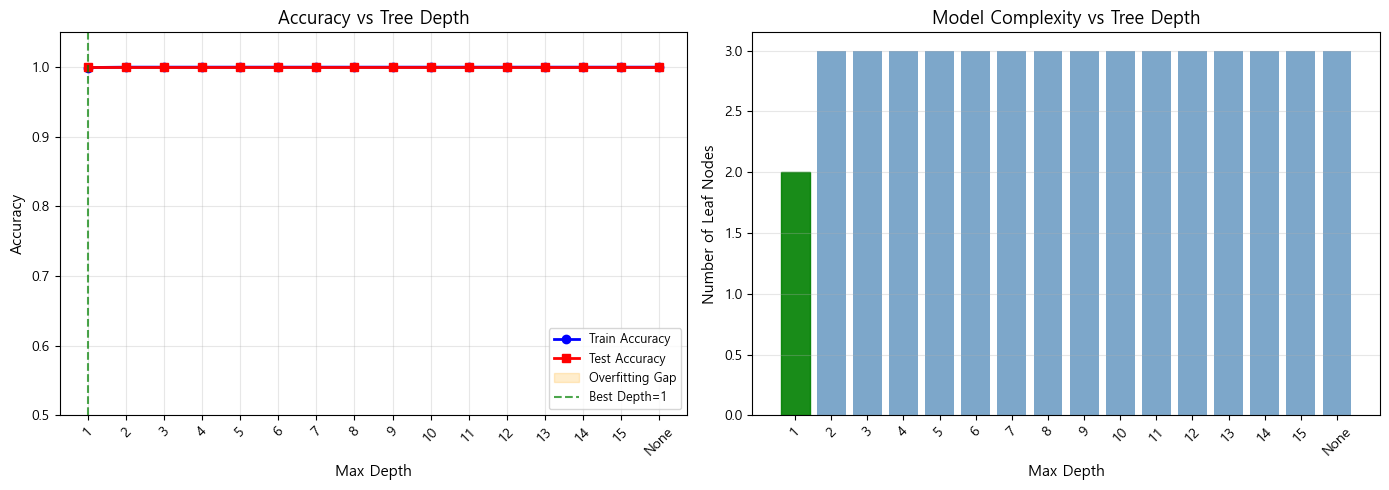


[과대적합 분석 결과]
1. 깊이가 증가할수록 학습 정확도는 계속 상승 (100%에 수렴)
2. 테스트 정확도는 일정 깊이 이후 정체 또는 하락
3. 학습-테스트 정확도 차이가 클수록 과대적합 심화
4. 리프 노드 수가 많을수록 복잡한 모델 (과대적합 위험)


In [19]:
# 과대적합 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: 깊이별 정확도
ax1 = axes[0]
depth_labels = [str(d) if d else 'None' for d in depths]
x_pos = range(len(depths))

ax1.plot(x_pos, train_scores, 'b-o', linewidth=2, markersize=6, label='Train Accuracy')
ax1.plot(x_pos, test_scores, 'r-s', linewidth=2, markersize=6, label='Test Accuracy')
ax1.fill_between(x_pos, train_scores, test_scores, alpha=0.2, color='orange', label='Overfitting Gap')

# 최적 깊이 표시
ax1.axvline(x=best_idx, color='green', linestyle='--', alpha=0.7, label=f'Best Depth={best_depth}')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(depth_labels, rotation=45)
ax1.set_xlabel('Max Depth', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy vs Tree Depth', fontsize=13)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.05)

# 그래프 2: 깊이별 리프 노드 수 (복잡도)
ax2 = axes[1]
bars = ax2.bar(x_pos, n_leaves_list, color='steelblue', alpha=0.7)

# 최적 깊이 강조
bars[best_idx].set_color('green')
bars[best_idx].set_alpha(0.9)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(depth_labels, rotation=45)
ax2.set_xlabel('Max Depth', fontsize=11)
ax2.set_ylabel('Number of Leaf Nodes', fontsize=11)
ax2.set_title('Model Complexity vs Tree Depth', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[과대적합 분석 결과]")
print("1. 깊이가 증가할수록 학습 정확도는 계속 상승 (100%에 수렴)")
print("2. 테스트 정확도는 일정 깊이 이후 정체 또는 하락")
print("3. 학습-테스트 정확도 차이가 클수록 과대적합 심화")
print("4. 리프 노드 수가 많을수록 복잡한 모델 (과대적합 위험)")

---

# Part 5: 트리 시각화와 해석

## 5.1 트리 구조 시각화

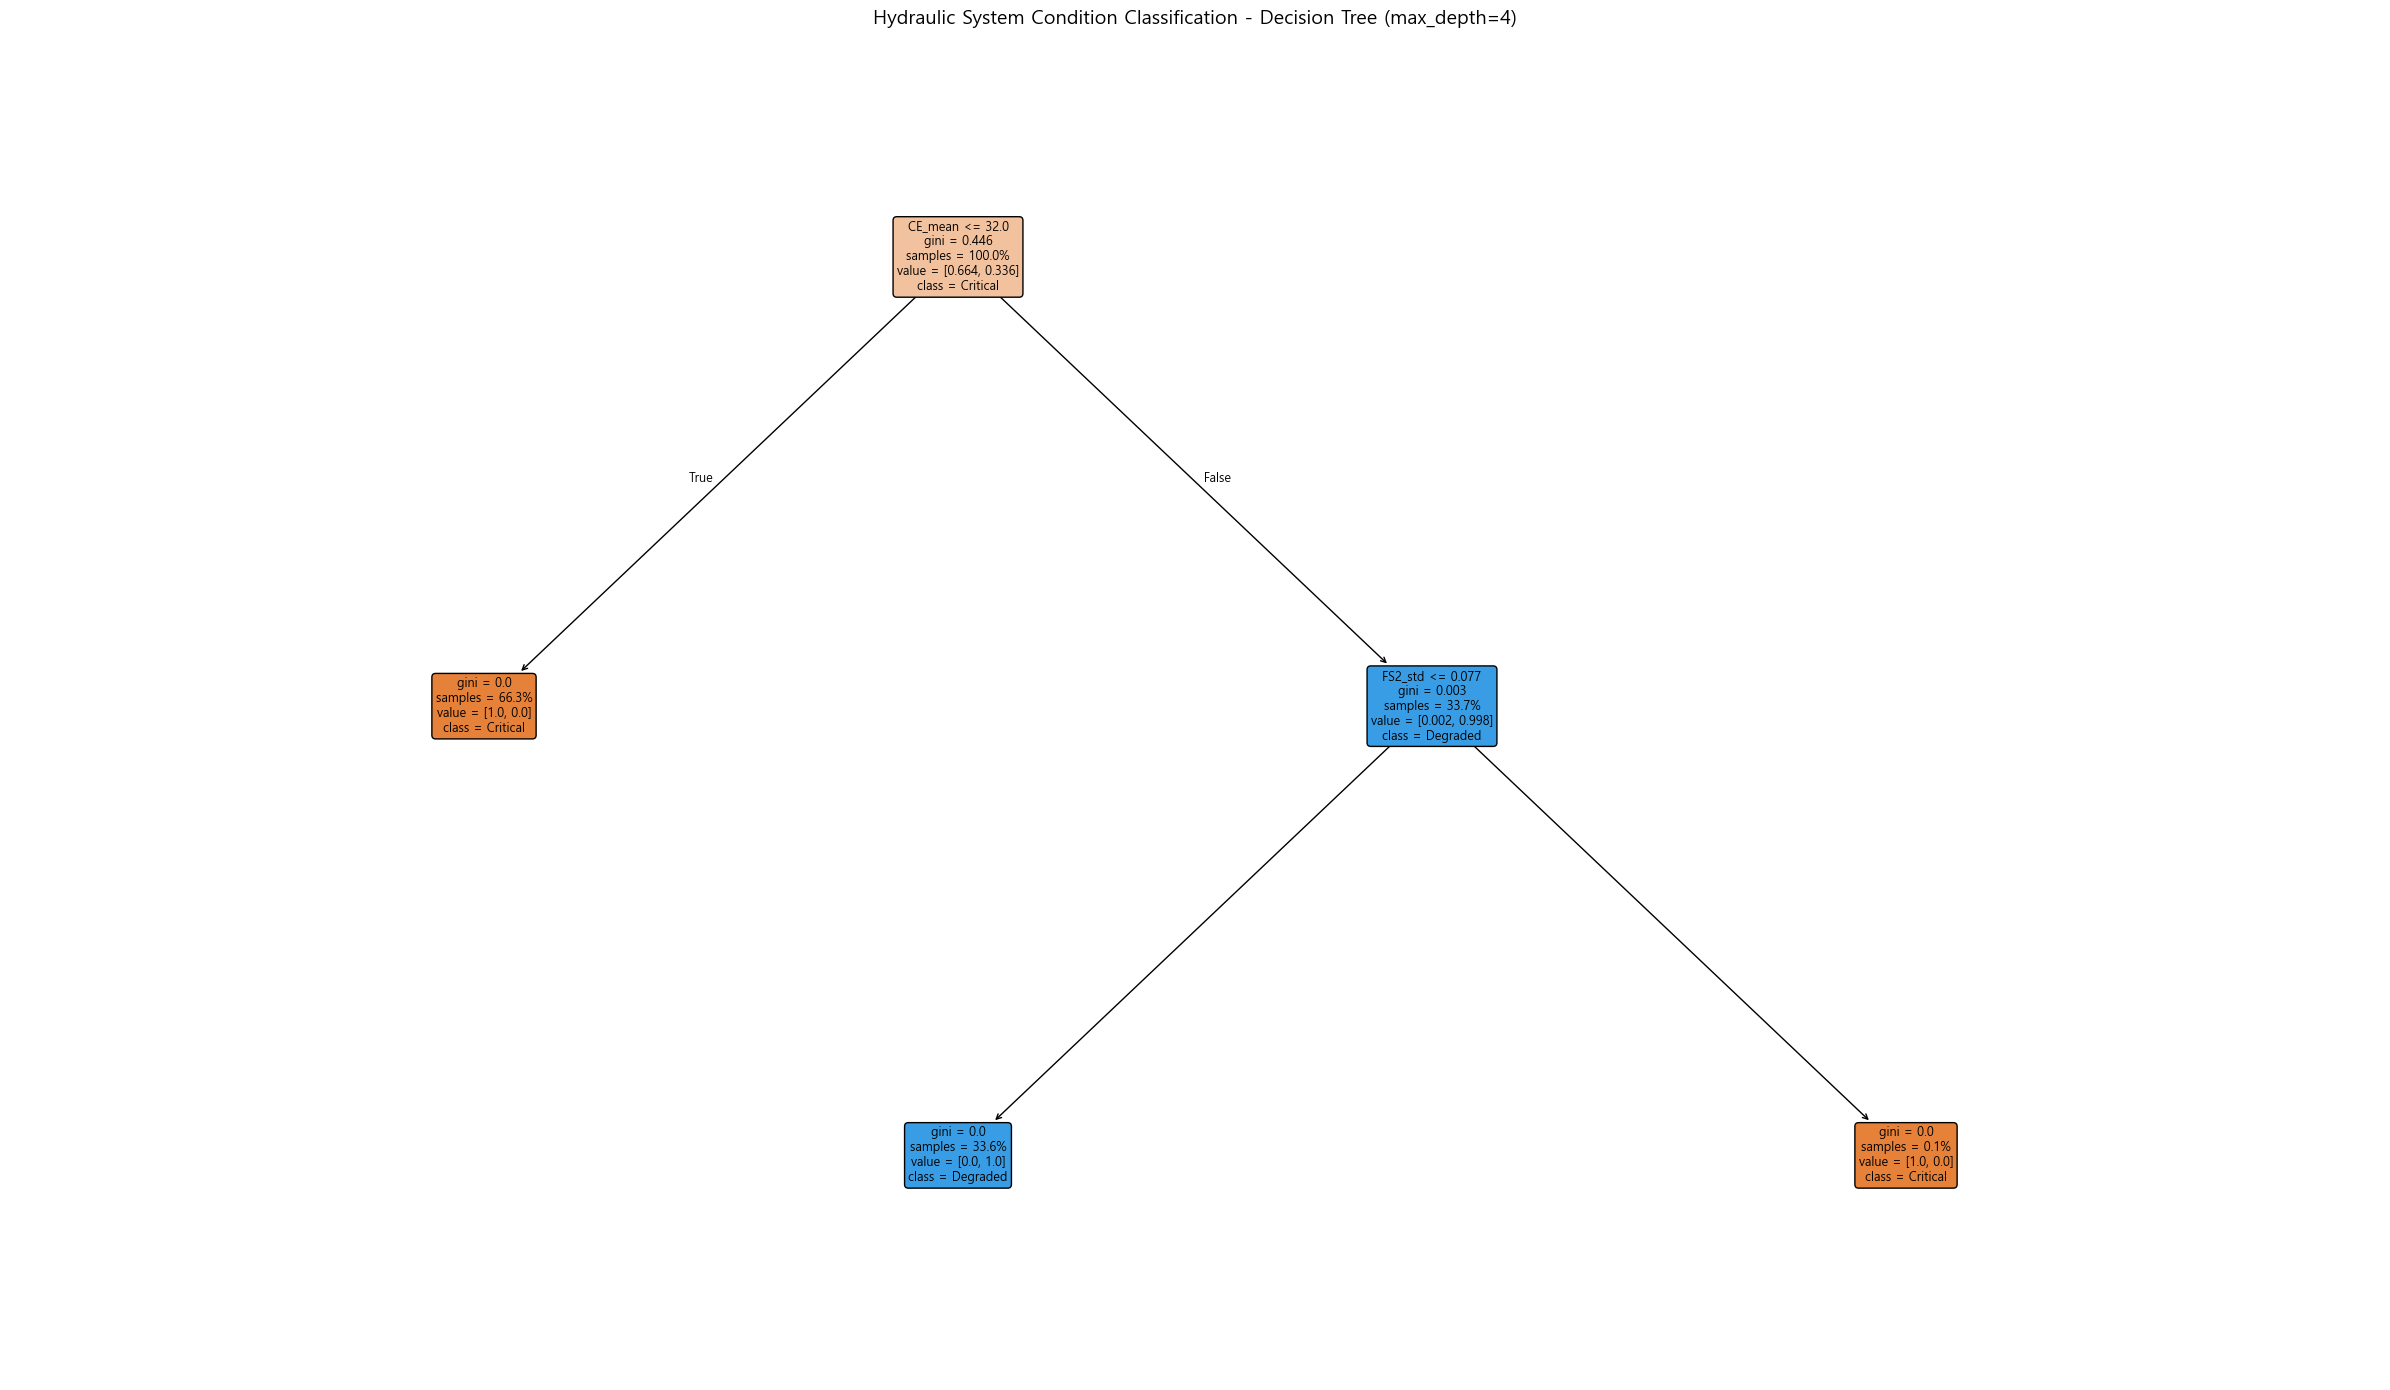

트리 깊이: 2
리프 노드 수: 3
테스트 정확도: 100.0%


In [20]:
# 시각화용 모델 (깊이 4로 제한)
model_viz = DecisionTreeClassifier(max_depth=4, random_state=42)
model_viz.fit(X_train, y_train)

# 트리 시각화
fig, ax = plt.subplots(figsize=(24, 14))

plot_tree(
    model_viz,
    feature_names=feature_cols,
    class_names=['Critical', 'Degraded', 'Optimal'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=True
)

plt.title("Hydraulic System Condition Classification - Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"트리 깊이: {model_viz.get_depth()}")
print(f"리프 노드 수: {model_viz.get_n_leaves()}")
print(f"테스트 정확도: {model_viz.score(X_test, y_test):.1%}")

In [ ]:
# 트리 규칙 텍스트 출력
print("=" * 70)
print("의사결정나무 분류 규칙")
print("=" * 70)

tree_rules = export_text(
    model_viz,
    feature_names=feature_cols
)
print(tree_rules)

## 5.2 특성 중요도 분석

의사결정나무는 각 특성이 분류에 얼마나 기여했는지를 **특성 중요도(Feature Importance)**로 정량화한다. 이는 해당 특성으로 분할했을 때 불순도 감소량의 가중 평균으로 계산된다.

In [ ]:
# 특성 중요도
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("=" * 70)
print("특성 중요도 (Feature Importance)")
print("=" * 70)

print(f"\n{'순위':>4} {'특성명':>20} {'중요도':>12}")
print("-" * 40)
for rank, idx in enumerate(sorted_idx, 1):
    if importances[idx] > 0:  # 중요도가 0보다 큰 특성만 표시
        print(f"{rank:>4} {feature_cols[idx]:>20} {importances[idx]:>12.4f}")

print(f"\n특성 중요도 합계: {importances.sum():.4f}")

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))

# 상위 10개 특성만 표시
top_n = 10
top_indices = sorted_idx[:top_n]
top_importances = importances[top_indices]
top_features = [feature_cols[i] for i in top_indices]

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(top_n)]
bars = ax.barh(range(top_n), top_importances, color=colors)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features)
ax.invert_yaxis()  # 가장 중요한 특성이 위로
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Top 10 Feature Importance - Decision Tree', fontsize=13)

# 값 표시
for i, (bar, imp) in enumerate(zip(bars, top_importances)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', fontsize=10)

ax.set_xlim(0, max(top_importances) * 1.15)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print(f"가장 중요한 특성: {feature_cols[sorted_idx[0]]} ({importances[sorted_idx[0]]:.3f})")
print("이 특성은 유압 시스템 상태 분류에 가장 큰 영향을 미침")

## 5.3 새로운 데이터 예측

In [ ]:
# 새로운 샘플에 대한 예측
print("=" * 70)
print("새로운 데이터 예측 시나리오")
print("=" * 70)

# 테스트 데이터에서 샘플 선택
sample_indices = [0, 50, 100, 150, 200]

print(f"\n{'샘플':>6} {'실제':>12} {'예측':>12} {'일치':>6} {'예측 확률':<30}")
print("-" * 70)

for i in sample_indices:
    if i < len(X_test):
        sample = X_test.iloc[[i]]
        actual = y_test.iloc[i]
        predicted = model.predict(sample)[0]
        proba = model.predict_proba(sample)[0]
        match = "O" if actual == predicted else "X"
        
        proba_str = f"Crit:{proba[0]:.0%} Deg:{proba[1]:.0%} Opt:{proba[2]:.0%}"
        print(f"{i:>6} {actual:>12} {predicted:>12} {match:>6} {proba_str:<30}")

print("\n[예측 해석]")
print("- 예측 확률이 높을수록 해당 클래스에 대한 확신도가 높음")
print("- 확률이 비슷하게 분포되면 경계 영역의 샘플일 가능성")

---

# 핵심 정리

## 의사결정나무 핵심 개념 요약

| 개념 | 설명 | 수식 |
|------|------|------|
| **의사결정나무** | 질문 기반으로 데이터를 분류하는 알고리즘 | - |
| **지니 불순도** | 데이터 섞임 정도 측정 | $\text{Gini} = 1 - \sum p_i^2$ |
| **엔트로피** | 정보이론 기반 불순도 측정 | $H = -\sum p_i \log_2 p_i$ |
| **정보 이득** | 분할로 인한 불순도 감소량 | $IG = I_{parent} - \sum w_i I_{child}$ |
| **max_depth** | 과대적합 방지용 깊이 제한 | - |
| **특성 중요도** | 분류에 기여하는 정도 (합계 = 1.0) | - |

## 주요 파라미터 가이드

| 파라미터 | 권장값 | 효과 | 과대적합 방지 |
|----------|--------|------|---------------|
| max_depth | 3~10 | 트리 깊이 제한 | 낮을수록 효과적 |
| min_samples_split | 5~20 | 분할 최소 조건 | 높을수록 효과적 |
| min_samples_leaf | 2~10 | 리프 최소 조건 | 높을수록 효과적 |
| criterion | 'gini' (기본) | 불순도 측정 | 유사한 결과 |

## 장단점 요약

| 장점 | 단점 |
|------|------|
| 해석 용이 (화이트박스 모델) | 과대적합 경향 |
| 전처리 불필요 (스케일링, 정규화) | 불안정 (데이터 변화에 민감) |
| 특성 중요도 제공 | 축 평행 분할만 가능 |
| 범주형/수치형 모두 처리 | 단일 트리 성능 한계 |
| 비선형 관계 학습 가능 | 클래스 불균형에 취약 |

---

# 다음 차시 예고

## 15차시: 분류 모델 (2) - 랜덤포레스트

| 주제 | 내용 |
|------|------|
| **앙상블 학습** | 여러 모델을 결합하여 성능 향상 |
| **배깅(Bagging)** | Bootstrap Aggregating 원리 |
| **랜덤포레스트** | 다수의 의사결정나무 결합 |
| **특성 중요도** | 앙상블에서의 특성 중요도 해석 |

다음 차시에서는 단일 의사결정나무의 한계를 극복하는 **앙상블 기법**과 **랜덤포레스트**를 학습한다.

---

# [참고자료] 추가 학습 내용

## 가지치기(Pruning) 기법

의사결정나무의 과대적합을 방지하기 위한 가지치기 기법은 크게 두 가지로 나뉜다.

| 방식 | 설명 | 구현 방법 |
|------|------|----------|
| **사전 가지치기** | 트리 성장 중 조기 종료 | max_depth, min_samples_split, min_samples_leaf |
| **사후 가지치기** | 완성된 트리에서 가지 제거 | ccp_alpha (비용 복잡도 가지치기) |

## 불균형 데이터 처리

제조업에서는 정상 제품이 대부분이고 불량 제품은 소수인 **클래스 불균형** 문제가 흔하다.

| 방법 | 설명 |
|------|------|
| class_weight='balanced' | 클래스 빈도에 반비례하여 가중치 자동 설정 |
| 수동 가중치 | 도메인 지식 기반 가중치 직접 설정 |
| 오버샘플링 | SMOTE 등으로 소수 클래스 증강 |
| 언더샘플링 | 다수 클래스 축소 |